# Microscope Design Curves

This notebook computes the complete set of **design curves** (lens focal lengths and drive currents) for a model TEM column, covering both operating modes:

| Mode | Control variable | Varied lenses | Fixed lenses |
|------|-----------------|---------------|--------------|
| **A — Condenser spot size** | Spot index (1–8) | CL1, CL3 | C_mini, Obj_prefield |
| **B — Intermediate-lens magnification** | System magnification (30k–600k×) | IL1, IL2, IL3 | Obj_post, PL1 |

### Key physics constraints

- **B = 0 imaging**: every IL solution places a real image exactly on the pre-PL1 object plane (|B| < 1 nm).
- **Rotation cancellation**: the total Larmor rotation of Obj_post + IL1 + IL2 + IL3 + PL1 sums to zero, so the image is not rotated on the detector.
- **No spurious images**: solutions that form an intermediate image between IL2 and IL3 are rejected.

### Geometry

The IL distances were optimised by differential evolution in `il_three_lens_constraint_study.ipynb` to closely match the DAC reference curves from a real microscope while keeping IL3 focal lengths physically reasonable (max ~800 mm rather than ~45,000 mm at baseline).

### Output

The notebook writes a `MicroscopeModel` NPZ file to `data/microscope_design_curves.npz`.

## 1 — Imports and Microscope Configuration

All physical dimensions, lens parameters, and solver targets are defined in the `sys_config` dictionary below. Distances are in **metres**, voltages in **volts**.

In [ ]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.01"

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import brentq, least_squares

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix
from temgym_core.constants import compute_Rc_from_voltage
from temgym_core.microscope_model import MicroscopeModel, OperatingMode, LensConfig


%matplotlib widget

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# ══════════════════════════════════════════════════════════════
# Master configuration
# ══════════════════════════════════════════════════════════════

sys_config = {

    # ── Beam ──
    'beam': {
        'voltage_kV': 200,
        'virtual_source_diameter_nm': 10.0,
        'source_half_angle_mrad': 0.05,
    },

    # ── Column geometry (all distances in metres) ──
    #
    #   Source ──d_Source_to_CL1──▷ CL1 ──d_CL1_to_CL3──▷ CL3
    #     ──d_CL3_to_Aperture──▷ Aperture ──d_Aperture_to_Cmini──▷ Cmini
    #     ──d_Cmini_to_ObjPrefield──▷ ObjPrefield ──d_ObjPrefield_to_Sample──▷ Sample
    #     ──d_Sample_to_ObjPost──▷ ObjPost ──d_ObjPost_to_IL1──▷ IL1
    #     ──d_IL1_to_IL2──▷ IL2 ──d_IL2_to_IL3──▷ IL3
    #     ──d_IL3_to_PL1──▷ PL1 ──d_PL1_to_detector──▷ Detector
    #
    #   The IL distances (IL1↔IL2, IL2↔IL3, IL3↔PL1) were optimised
    #   by differential evolution in il_three_lens_constraint_study.ipynb.
    #
    'geometry': {
        'd_Source_to_CL1':          0.200,
        'd_CL1_to_CL3':            0.040,
        'd_CL3_to_Aperture':       10.0e-3,
        'd_Aperture_to_Cmini':     50.0e-3,
        'd_Cmini_to_ObjPrefield':  20.0e-3,
        'd_ObjPrefield_to_Sample':  5.0e-3,
        'd_Sample_to_ObjPost':      2.3e-3,
        'd_ObjPost_to_IL1':       100.0e-3,
        'd_IL1_to_IL2':            61.233e-3,
        'd_IL2_to_IL3':            68.851e-3,
        'd_IL3_to_PL1':            47.449e-3,
        'd_PL1_to_detector':        0.325,
    },

    # ── Lens optics ──
    #   Gc: focal-power coefficient, 1/f = Gc · NI²  [1/(m · AT²)]
    #   turns: number of turns in each coil
    #
    'optics': {
        'f_Cmini_m':       5.0e-3,
        'f_ObjPrefield_m': 5.0e-3,
        'CL1':        {'turns': 3000, 'Gc': 8.0e-6},
        'CL3':        {'turns': 3600, 'Gc': 4.0e-6},
        'Cmini':      {'turns': 2000},
        'ObjPrefield':{'turns': 3000, 'Gc': 8.0e-6},
        'ObjPost':    {'turns': 3000, 'Gc': 8.0e-6},
        'IL1':        {'turns': 3000, 'Gc': 8.0e-6},
        'IL2':        {'turns': 2000, 'Gc': 8.0e-6},
        'IL3':        {'turns': 2000, 'Gc': 8.0e-6},
        'PL1':        {'turns': 2000, 'Gc': 8.0e-6},
    },

    # ── Solver targets ──
    'solver_targets': {
        'condenser_spots': {
            'N_spots': 8,
            'target_sample_min_nm': 500.0,
            'target_sample_max_nm': 5000.0,
            'I_A_bounds':      {'CL1': (0.4, 1.9), 'CL3': (0.4, 1.9)},
            'f_solver_bounds':  {'CL1': (0.8e-3, 120.0e-3), 'CL3': (0.8e-3, 900.0e-3)},
            'f_tens_bounds':    {'CL1': (5.0e-3, 30.0e-3), 'CL3': (5.0e-3, 30.0e-3)},
            'scan_points': 2500,
        },
        'magnification_steps': {
            'M_obj':  -30.0,
            'M_proj':  100.0,
            'd_obj_image_to_il1_target_m': 9.083e-3,   # DE-optimised
            'target_system_mags': np.array([30_000, 50_000, 100_000, 300_000, 600_000], dtype=float),
        },
        'diffraction_steps': {
            # Camera length Lc is defined as |M_bfp| * f_obj.
            # This range is chosen to stay within the feasible BFP relay envelope
            # of the current IL geometry while still covering practical TEM values.
            'target_camera_lengths_m': np.array([0.02, 0.04, 0.08, 0.12, 0.18], dtype=float),
            'f_bounds_m': {
                'IL1': (2.0e-3, 80.0e-3),
                'IL2': (1.5e-3, 80.0e-3),
                'IL3': (2.0e-3, 200.0e-3),
            },
        },
    },
}

# ══════════════════════════════════════════════════════════════
# Derived quantities
# ══════════════════════════════════════════════════════════════

U_accel_V = sys_config['beam']['voltage_kV'] * 1000.0
Rc_phys = float(compute_Rc_from_voltage(U_accel_V))    # Larmor rotation constant [rad/AT]

# --- Condenser geometry ---
geometry_cond = {
    'd_S_C1':      sys_config['geometry']['d_Source_to_CL1'],
    'd_C1_C3':     sys_config['geometry']['d_CL1_to_CL3'],
    'd_C3_A':      sys_config['geometry']['d_CL3_to_Aperture'],
    'd_A_Cmini':   sys_config['geometry']['d_Aperture_to_Cmini'],
    'd_Cmini_OPL': sys_config['geometry']['d_Cmini_to_ObjPrefield'],
    'f_Cmini':     sys_config['optics']['f_Cmini_m'],
    'f_OPL':       sys_config['optics']['f_ObjPrefield_m'],
}

turns_cond    = {k: sys_config['optics'][k]['turns'] for k in ['CL1', 'CL3']}
Gc_phys_cond  = {k: sys_config['optics'][k]['Gc']    for k in ['CL1', 'CL3']}
I_A_bounds_cond = sys_config['solver_targets']['condenser_spots']['I_A_bounds']
AT_bounds_cond  = {k: (turns_cond[k] * lo, turns_cond[k] * hi) for k, (lo, hi) in I_A_bounds_cond.items()}

N_spots                      = sys_config['solver_targets']['condenser_spots']['N_spots']
f3_scan_points               = sys_config['solver_targets']['condenser_spots']['scan_points']
sample_rel_tolerance         = 2e-2
conjugate_eps                = 1e-6
requested_sample_target_min_nm = sys_config['solver_targets']['condenser_spots']['target_sample_min_nm']
requested_sample_target_max_nm = sys_config['solver_targets']['condenser_spots']['target_sample_max_nm']
f_solver_bounds_cond         = sys_config['solver_targets']['condenser_spots']['f_solver_bounds']
enforce_tens_mm_cond         = True
f_tens_bounds_cond           = sys_config['solver_targets']['condenser_spots']['f_tens_bounds']

virtual_source_diameter_nm   = sys_config['beam']['virtual_source_diameter_nm']
source_half_angle_mrad       = sys_config['beam']['source_half_angle_mrad']
sample_distance_from_opl_m   = geometry_cond['f_OPL']
source_sigma_x_m             = 0.5 * virtual_source_diameter_nm * 1e-9
source_sigma_theta_rad       = source_half_angle_mrad * 1e-3

# --- Magnification targets ---
M_obj              = sys_config['solver_targets']['magnification_steps']['M_obj']
M_proj             = sys_config['solver_targets']['magnification_steps']['M_proj']
target_system_mags = sys_config['solver_targets']['magnification_steps']['target_system_mags']
M_mag_targets      = target_system_mags / (M_obj * M_proj)   # IL-only magnification needed

# --- Objective imaging: sample → real image before IL1 ---
#   Thin-lens imaging:  1/f = 1/u + 1/v,  M = -v/u
#   u = d_Sample_to_ObjPost,  v = |M_obj| · u
u_obj_m = sys_config['geometry']['d_Sample_to_ObjPost']
v_obj_m = abs(M_obj) * u_obj_m
f_obj_required_m = u_obj_m * v_obj_m / (u_obj_m + v_obj_m)

d_obj_image_to_il1_target = float(
    sys_config['solver_targets']['magnification_steps'].get('d_obj_image_to_il1_target_m', np.nan)
)
if np.isfinite(d_obj_image_to_il1_target):
    if d_obj_image_to_il1_target <= 0:
        raise ValueError('d_obj_image_to_il1_target_m must be > 0.')
    d_obj_image_to_il1 = float(d_obj_image_to_il1_target)
    d_ObjPost_to_IL1 = float(v_obj_m + d_obj_image_to_il1)
else:
    d_ObjPost_to_IL1 = float(sys_config['geometry']['d_ObjPost_to_IL1'])
    d_obj_image_to_il1 = float(d_ObjPost_to_IL1 - v_obj_m)

if d_obj_image_to_il1 <= 0:
    raise ValueError(
        f'Objective image at v={v_obj_m*1e3:.1f} mm past Obj_post exceeds '
        f'd_ObjPost_to_IL1={d_ObjPost_to_IL1*1e3:.1f} mm. '
        'Increase d_ObjPost_to_IL1 or set d_obj_image_to_il1_target_m.'
    )

# --- Projector geometry ---
#   PL1 images the IL exit plane onto the detector:
#     d_pre_PL1_image_to_PL1 = d_PL1_to_detector / |M_proj|
d_pre_PL1_image_to_PL1 = sys_config['geometry']['d_PL1_to_detector'] / abs(M_proj)

geometry_proj = {
    'd_il3_to_pl1':            sys_config['geometry']['d_IL3_to_PL1'],
    'd_pre_pl1_image_to_pl1':  d_pre_PL1_image_to_PL1,
    'd_pl1_to_detector':       sys_config['geometry']['d_PL1_to_detector'],
}

# --- IL geometry (the transfer-matrix distances seen by the solver) ---
geometry_mag = {
    'd_obj_image_to_il1': d_obj_image_to_il1,
    'd_il1_to_il2':       sys_config['geometry']['d_IL1_to_IL2'],
    'd_il2_to_il3':       sys_config['geometry']['d_IL2_to_IL3'],
    'd_il3_to_image':     geometry_proj['d_il3_to_pl1'] - geometry_proj['d_pre_pl1_image_to_pl1'],
}

# --- Diffraction geometry (BFP relay) ---
#   Objective back focal plane is f_obj downstream of Obj_post.
#   IL chain now starts from the BFP instead of the objective image plane.
d_bfp_to_il1 = float(d_ObjPost_to_IL1 - f_obj_required_m)
if d_bfp_to_il1 <= 0:
    raise ValueError('Invalid diffraction geometry: BFP must be upstream of IL1.')

geometry_diff = {
    'd_bfp_to_il1':       d_bfp_to_il1,
    'd_il1_to_il2':       sys_config['geometry']['d_IL1_to_IL2'],
    'd_il2_to_il3':       sys_config['geometry']['d_IL2_to_IL3'],
    'd_il3_to_image':     geometry_mag['d_il3_to_image'],
}

target_camera_lengths_m = np.asarray(
    sys_config['solver_targets']['diffraction_steps']['target_camera_lengths_m'],
    dtype=float,
)
# Keep negative sign convention consistent with the imaging-mode IL magnifications.
M_diff_targets = -target_camera_lengths_m / f_obj_required_m
f_bounds_diff = sys_config['solver_targets']['diffraction_steps']['f_bounds_m']

f_pl1_target_m = 1.0 / (1.0 / geometry_proj['d_pre_pl1_image_to_pl1'] + 1.0 / geometry_proj['d_pl1_to_detector'])
turns_mag   = {k: sys_config['optics'][k]['turns'] for k in ['IL1', 'IL2', 'IL3']}
Gc_phys_mag = {k: sys_config['optics'][k]['Gc']    for k in ['IL1', 'IL2', 'IL3']}

# --- Rotation cancellation ---
#   ObjPost and PL1 are at fixed currents.  The IL system must produce
#   a total Larmor rotation of theta_target = Rc · (NI_objpost + NI_pl1)
#   so that the net rotation across the whole post-specimen column is zero.
Gc_objpost_cfg = sys_config['optics']['ObjPost']['Gc']
Gc_pl1_cfg     = sys_config['optics']['PL1']['Gc']
ni_objpost_mag = float(np.sqrt(1.0 / (Gc_objpost_cfg * f_obj_required_m)))
ni_pl1_mag     = float(np.sqrt(1.0 / (Gc_pl1_cfg * f_pl1_target_m)))
theta_target   = float(Rc_phys * (ni_objpost_mag + ni_pl1_mag))

# --- Summary ---
print(f'Rc = {Rc_phys:.4e} rad/AT')
print(f'Objective: M_obj = {M_obj},  u = {u_obj_m*1e3:.3f} mm,  v = {v_obj_m*1e3:.3f} mm,  '
      f'f = {f_obj_required_m*1e3:.4f} mm,  NI = {ni_objpost_mag:.1f} AT')
print(f'd_obj_image → IL1 = {d_obj_image_to_il1*1e3:.3f} mm  '
      f'(d_ObjPost → IL1 = {d_ObjPost_to_IL1*1e3:.3f} mm)')
print(f'BFP → IL1 (diffraction mode) = {d_bfp_to_il1*1e3:.3f} mm')
print(f'IL geometry [mm]:  IL1↔IL2 = {geometry_mag["d_il1_to_il2"]*1e3:.3f},  '
      f'IL2↔IL3 = {geometry_mag["d_il2_to_il3"]*1e3:.3f},  '
      f'IL3↔image = {geometry_mag["d_il3_to_image"]*1e3:.3f}')
print(f'PL1: f = {f_pl1_target_m*1e3:.4f} mm,  d_IL3↔PL1 = {geometry_proj["d_il3_to_pl1"]*1e3:.3f} mm')
print(f'Magnification targets: {target_system_mags.astype(int).tolist()}')
print(f'Diffraction camera lengths [m]: {target_camera_lengths_m.tolist()}')
print(f'theta_target = {np.rad2deg(theta_target):.2f}°')

Rc = 5.3015e-04 rad/AT
Objective: M_obj = -30.0,  u = 2.300 mm,  v = 69.000 mm,  f = 2.2258 mm,  NI = 7494.0 AT
d_obj_image → IL1 = 9.083 mm  (d_ObjPost → IL1 = 78.083 mm)
BFP → IL1 (diffraction mode) = 75.857 mm
IL geometry [mm]:  IL1↔IL2 = 61.233,  IL2↔IL3 = 68.851,  IL3↔image = 44.199
PL1: f = 3.2178 mm,  d_IL3↔PL1 = 47.449 mm
Magnification targets: [30000, 50000, 100000, 300000, 600000]
Diffraction camera lengths [m]: [0.02, 0.04, 0.08, 0.12, 0.18]
theta_target = 416.95°


## 2 — Transfer-Matrix Primitives and Shared Helpers

These utility functions are used by both the condenser and IL solvers:
- `build_chain` / `extract_abcd` — compose 3×3 transfer matrices and extract the 2×2 ABCD elements.
- `currents_from_focal_lengths` — convert focal lengths to coil currents via $1/f = G_c \cdot NI^2$.
- `scalar_root_solve` — bracket-and-Brentq root finder for design-curve residuals.
- `focal_bounds_from_current_bounds` — invert current limits into focal-length limits.

In [8]:
# ── Transfer-matrix composition ──

def build_chain(elements, xp=np):
    """Compose a sequence of propagation ('P', d) and lens ('L', f) elements."""
    M = xp.eye(3)
    for kind, value in elements:
        if kind == 'P':
            op = propagation_matrix(value, xp=xp)
        elif kind == 'L':
            op = lens_matrix(value, xp=xp)
        else:
            raise ValueError(f'Unknown element kind: {kind}')
        M = op @ M
    return M


def extract_abcd(M):
    """Extract (A, B, C, D) from a 3×3 transfer matrix."""
    return M[0, 0], M[0, 1], M[1, 0], M[1, 1]


# ── Focal length ↔ current conversion ──

def currents_from_focal_lengths(f_map, gc_phys_map, turns_map):
    """Convert {lens_name: focal_length} to {I_A_name, AT_name} using 1/f = Gc·NI²."""
    out = {}
    for k, f in f_map.items():
        if (not np.isfinite(f)) or (f <= 0.0):
            return None
        at = float(np.sqrt(1.0 / (gc_phys_map[k] * f)))
        out[f'I_A_{k}'] = float(at / turns_map[k])
        out[f'AT_{k}'] = at
    return out


def apply_hard_bounds_and_flag(row, i_a_bounds, at_bounds):
    """Return True if all currents in `row` are within bounds."""
    for k, (lo, hi) in i_a_bounds.items():
        if not (lo <= row[f'I_A_{k}'] <= hi):
            return False
    for k, (lo, hi) in at_bounds.items():
        if not (lo <= row[f'AT_{k}'] <= hi):
            return False
    return True


# ── Root-finding helpers ──

def choose_bracket(f_grid, r_grid, prev_root=None):
    """Find a sign-change bracket in (f_grid, r_grid), preferring one near prev_root."""
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g = f_grid[finite]
    r = r_grid[finite]

    candidates = []
    for a, b, ra, rb in zip(g[:-1], g[1:], r[:-1], r[1:]):
        if ra == 0.0:
            candidates.append((float(a), float(a)))
        elif ra * rb < 0.0:
            candidates.append((float(a), float(b)))

    if len(candidates) == 0:
        return None
    if prev_root is None:
        return candidates[0]

    mids = np.array([0.5 * (a + b) for (a, b) in candidates], dtype=float)
    j = int(np.argmin(np.abs(mids - prev_root)))
    return candidates[j]


def scalar_root_solve(residual_fn, f_grid, prev_root=None, maxiter=200):
    """Bracket-and-Brentq root finder.  Falls back to nearest-to-zero if no bracket."""
    r_grid = np.array([residual_fn(float(x)) for x in f_grid], dtype=float)
    bracket = choose_bracket(f_grid, r_grid, prev_root=prev_root)

    converged = False
    if bracket is None:
        finite = np.isfinite(r_grid)
        if not np.any(finite):
            raise RuntimeError('No finite residuals in scalar_root_solve')
        g = f_grid[finite]
        r = r_grid[finite]
        root = float(g[np.argmin(np.abs(r))])
    elif bracket[0] == bracket[1]:
        root = float(bracket[0])
        converged = True
    else:
        root = float(brentq(lambda x: residual_fn(float(x)), bracket[0], bracket[1], maxiter=maxiter))
        converged = True

    return root, converged


# ── Focal-length bounds from current limits ──

def focal_bounds_from_current_bounds(gc_phys, turns, i_min, i_max):
    """Invert I_min/I_max into (f_min, f_max) via 1/f = Gc·(N·I)²."""
    return 1.0 / (gc_phys * (turns * i_max)**2), 1.0 / (gc_phys * (turns * i_min)**2)


f_phys_bounds = {
    k: focal_bounds_from_current_bounds(Gc_phys_cond[k], turns_cond[k], *I_A_bounds_cond[k])
    for k in turns_cond
}
f_bounds_cond = {
    k: (
        max(f_solver_bounds_cond[k][0], f_phys_bounds[k][0]),
        min(f_solver_bounds_cond[k][1], f_phys_bounds[k][1]),
    )
    for k in turns_cond
}
if enforce_tens_mm_cond:
    f_bounds_cond = {
        k: (
            max(f_bounds_cond[k][0], f_tens_bounds_cond[k][0]),
            min(f_bounds_cond[k][1], f_tens_bounds_cond[k][1]),
        )
        for k in turns_cond
    }
    for k, (lo, hi) in f_bounds_cond.items():
        if lo >= hi:
            raise ValueError(f'No feasible focal range for {k}: bounds={f_bounds_cond[k]}')

print(f'Condenser focal bounds [mm]: { {k: tuple(round(1e3*x, 2) for x in v) for k, v in f_bounds_cond.items()} }')

Condenser focal bounds [mm]: {'CL1': (5.0, 30.0), 'CL3': (5.34, 30.0)}


## 3 — Mode A: Condenser Spot-Size Design Curves

The condenser system images the virtual source onto the sample through CL1 → CL3 → C_mini → Obj_prefield.  C_mini and Obj_prefield are at fixed focal lengths; only CL1 and CL3 vary.

**Approach:**
1. Compute the C_mini conjugate geometry (fixed imaging through C_mini + Obj_prefield).
2. Scan CL3 focal length over the allowed range; for each CL3, numerically solve for CL1 such that B = 0 at the C_mini object plane (real image condition).
3. Propagate the Gaussian source beam through the full condenser chain and compute the FWHM sample spot size.
4. Invert the FWHM(f_CL3) curve at N geometrically-spaced target spot sizes to get N spot-index settings.

In [9]:
# ── C_mini conjugate calculation ──
#
#   C_mini images a point in the CL3→Aperture space to the Obj_prefield
#   focal plane.  d_obj_cmini is the object distance for C_mini;
#   d_img_fopl is the image distance (= d_Cmini_to_ObjPrefield - f_OPL).

def compute_cmini_conjugate_distance(geom, eps):
    d_img_fopl = float(geom['d_Cmini_OPL'] - geom['f_OPL'])
    f_cmini = float(geom['f_Cmini'])
    d_c3_to_cmini = float(geom['d_C3_A'] + geom['d_A_Cmini'])

    if not np.isfinite(d_img_fopl):
        raise ValueError('Invalid d_img_fopl (non-finite).')
    if not (d_img_fopl > f_cmini + eps):
        raise ValueError(
            'Invalid CLmini conjugate geometry: require d_img_fopl > f_Cmini + eps. '
            f'Got d_img_fopl={d_img_fopl:.6e}, f_Cmini={f_cmini:.6e}, eps={eps:.1e}.'
        )

    denom = (1.0 / f_cmini) - (1.0 / d_img_fopl)
    if abs(denom) <= 1e-15:
        raise ValueError('Invalid CLmini conjugate geometry (denominator near zero).')

    d_obj_cmini = 1.0 / denom
    if (not np.isfinite(d_obj_cmini)) or (d_obj_cmini <= 0.0):
        raise ValueError(f'Invalid d_obj_cmini from conjugate calculation: {d_obj_cmini:.6e}.')
    if not (d_obj_cmini < d_c3_to_cmini):
        raise ValueError(
            'Invalid CLmini object-plane location: require d_obj_cmini < d_C3_A + d_A_Cmini.'
        )

    drift_to_ocmini = d_c3_to_cmini - d_obj_cmini
    return float(d_img_fopl), float(d_obj_cmini), float(drift_to_ocmini)


d_img_fopl, d_obj_cmini, drift_to_ocmini = compute_cmini_conjugate_distance(geometry_cond, conjugate_eps)
print(f'CLmini conjugate: d_img_fopl = {d_img_fopl*1e3:.4f} mm, '
      f'd_obj_cmini = {d_obj_cmini*1e3:.4f} mm, drift = {drift_to_ocmini*1e3:.4f} mm')


# ── Condenser transfer matrices ──

def system_matrix_pre(f_cl1, f_cl3, geom, d_obj_cmini_local):
    """Source → C_mini object plane (CL1 + CL3 only)."""
    drift = (geom['d_C3_A'] + geom['d_A_Cmini']) - d_obj_cmini_local
    elems = [
        ('P', geom['d_S_C1']),
        ('L', f_cl1),
        ('P', geom['d_C1_C3']),
        ('L', f_cl3),
        ('P', drift),
    ]
    return build_chain(elems, xp=np)


def system_matrix_cond_to_fopl(f_cl1, f_cl3, geom, d_obj_cmini_local, d_img_fopl_local):
    """Source → Obj_prefield focal plane (CL1 + CL3 + C_mini)."""
    M_pre = system_matrix_pre(f_cl1, f_cl3, geom, d_obj_cmini_local)
    M_cmini = build_chain([
        ('P', d_obj_cmini_local),
        ('L', geom['f_Cmini']),
        ('P', d_img_fopl_local),
    ], xp=np)
    return M_cmini @ M_pre


def system_matrix_fopl_to_sample(geom, z_sample):
    """Obj_prefield focal plane → sample."""
    return build_chain([
        ('P', geom['f_OPL']),
        ('L', geom['f_OPL']),
        ('P', z_sample),
    ], xp=np)


# ── Gaussian beam propagation ──

def q_inv_from_source_model(sigma_x_m, sigma_theta_rad, wavelength_m):
    """Build complex 1/q from source size and divergence."""
    if not (np.isfinite(sigma_x_m) and sigma_x_m > 0.0):
        raise ValueError(f'Invalid sigma_x_m={sigma_x_m}')
    if not (np.isfinite(sigma_theta_rad) and sigma_theta_rad > 0.0):
        raise ValueError(f'Invalid sigma_theta_rad={sigma_theta_rad}')
    if not (np.isfinite(wavelength_m) and wavelength_m > 0.0):
        raise ValueError(f'Invalid wavelength_m={wavelength_m}')

    w = 2.0 * sigma_x_m
    q_inv_im = wavelength_m / (np.pi * w * w)

    sigma_theta_diff = wavelength_m / (2.0 * np.pi * w)
    sigma_theta_curv_sq = max(sigma_theta_rad**2 - sigma_theta_diff**2, 0.0)

    if sigma_theta_curv_sq <= 0.0:
        q_inv_re = 0.0
    else:
        q_inv_re = float(np.sqrt(sigma_theta_curv_sq)) / sigma_x_m

    return complex(q_inv_re, q_inv_im)


def propagate_q_inv_abcd(q_inv_in, M_2x2, tiny=1e-15):
    """ABCD-law propagation: q_out^{-1} = (C + D·q_in^{-1}) / (A + B·q_in^{-1})."""
    A, B = float(M_2x2[0, 0]), float(M_2x2[0, 1])
    C, D = float(M_2x2[1, 0]), float(M_2x2[1, 1])
    denom = A + B * q_inv_in
    if abs(denom) <= tiny:
        return None
    return (C + D * q_inv_in) / denom


def fwhm_from_q_inv(q_inv_out, wavelength_m):
    """Beam FWHM from the imaginary part of 1/q."""
    q_inv_im = float(np.imag(q_inv_out))
    if not (np.isfinite(q_inv_im) and q_inv_im > 0.0):
        return np.inf
    w = np.sqrt(wavelength_m / (np.pi * q_inv_im))
    return float(w * np.sqrt(2.0 * np.log(2.0)))


# ── Staged real-imaging constraint ──

def lens_image_distance(f_lens, s_object, tiny=1e-15):
    denom = (1.0 / f_lens) - (1.0 / s_object)
    if abs(denom) <= tiny:
        return None
    s_image = 1.0 / denom
    return float(s_image) if np.isfinite(s_image) else None


def enforce_staged_real_imaging(f_cl1, f_cl3, geom, d_obj_cmini_local, residual_tol=1e-5, tiny=1e-12):
    """Check that CL1 forms a real image between CL1 and CL3, and CL3 relays it to the C_mini object plane."""
    s1 = float(geom['d_S_C1'])
    d12 = float(geom['d_C1_C3'])
    s3p = float((geom['d_C3_A'] + geom['d_A_Cmini']) - d_obj_cmini_local)

    if min(s1, d12, s3p) <= tiny:
        return None

    s1p = lens_image_distance(f_cl1, s1, tiny=tiny)
    if (s1p is None) or (s1p <= tiny):
        return None
    if not (s1p < d12 - tiny):
        return None

    s3 = float(d12 - s1p)
    if s3 <= tiny:
        return None

    r3 = 1.0/f_cl3 - 1.0/s3 - 1.0/s3p
    scale = max(abs(1.0/f_cl3), abs(1.0/s3) + abs(1.0/s3p), 1.0)
    if abs(r3) > residual_tol * scale:
        return None

    M_joint = build_chain([
        ('P', s1), ('L', f_cl1), ('P', d12), ('L', f_cl3), ('P', s3p),
    ], xp=np)
    _, B_joint, _, _ = extract_abcd(M_joint)

    return {
        's1_obj_m': float(s1), 's1_img_m': float(s1p),
        's3_obj_m': float(s3), 's3_img_m': float(s3p),
        'r3_residual': float(r3), 'B_joint': float(B_joint),
    }


imaging_residual_tol = 1e-5


# ── Source beam and fixed optics ──

lambda_e_m = float(12.264306e-10 / np.sqrt(U_accel_V * (1.0 + 0.978466e-6 * U_accel_V)))
q_inv_source = q_inv_from_source_model(source_sigma_x_m, source_sigma_theta_rad, lambda_e_m)
print(f'Source q⁻¹: Re = {np.real(q_inv_source):.3e}, Im = {np.imag(q_inv_source):.3e} 1/m  '
      f'(λ = {lambda_e_m*1e12:.4f} pm)')

M_fopl_to_sample = system_matrix_fopl_to_sample(geometry_cond, sample_distance_from_opl_m)
A_fs, B_fs, _, _ = extract_abcd(M_fopl_to_sample)
print(f'ObjPrefield → sample: A = {float(A_fs):.3e},  B = {float(B_fs):.3e} m/rad')


# ── Candidate evaluator (one CL3 focal length → full condenser solution) ──

def f1_from_f3_numeric_pre(f3, geom, f1_lo, f1_hi, d_obj_cmini_local, n_scan=500):
    """Given f_CL3, find f_CL1 such that B_pre = 0 (image at C_mini object plane)."""
    f1_grid = np.geomspace(f1_lo, f1_hi, int(n_scan))
    def b_pre_of_f1(x):
        M_pre = system_matrix_pre(x, f3, geom, d_obj_cmini_local)
        _, B_pre, _, _ = extract_abcd(M_pre)
        return float(B_pre)
    root, _ = scalar_root_solve(b_pre_of_f1, f1_grid, prev_root=None, maxiter=200)
    return float(root)


def evaluate_candidate_cond(f3, geom, f_bounds_local, d_obj_cmini_local, d_img_fopl_local):
    """Evaluate one condenser candidate at a given f_CL3.  Returns dict or None."""
    if not np.isfinite(f3) or f3 <= 0:
        return None
    if not (f_bounds_local['CL3'][0] <= f3 <= f_bounds_local['CL3'][1]):
        return None

    f1 = f1_from_f3_numeric_pre(f3, geom, f_bounds_local['CL1'][0], f_bounds_local['CL1'][1], d_obj_cmini_local)
    if not np.isfinite(f1) or f1 <= 0:
        return None
    if not (f_bounds_local['CL1'][0] <= f1 <= f_bounds_local['CL1'][1]):
        return None

    staged = enforce_staged_real_imaging(f1, f3, geom, d_obj_cmini_local, residual_tol=imaging_residual_tol)
    if staged is None:
        return None

    M_pre = system_matrix_pre(f1, f3, geom, d_obj_cmini_local)
    A_pre, B_pre, _, _ = extract_abcd(M_pre)

    M_sfopl = system_matrix_cond_to_fopl(f1, f3, geom, d_obj_cmini_local, d_img_fopl_local)
    A_fopl, B_fopl, _, _ = extract_abcd(M_sfopl)

    M_total = M_fopl_to_sample @ M_sfopl
    M_total_2x2 = np.asarray(M_total[:2, :2], dtype=float)
    q_inv_sample = propagate_q_inv_abcd(q_inv_source, M_total_2x2)
    if q_inv_sample is None:
        return None

    fwhm_sample_nm = float(fwhm_from_q_inv(q_inv_sample, lambda_e_m) * 1e9)
    if not np.isfinite(fwhm_sample_nm):
        return None

    cur = currents_from_focal_lengths({'CL1': f1, 'CL3': f3}, Gc_phys_cond, turns_cond)
    if cur is None:
        return None
    if not apply_hard_bounds_and_flag(cur, I_A_bounds_cond, AT_bounds_cond):
        return None

    out = {
        'f_CL1': float(f1), 'f_CL3': float(f3),
        'A_pre_abs': float(abs(A_pre)), 'A_fopl_abs': float(abs(A_fopl)),
        'B_pre': float(B_pre), 'B_fopl': float(B_fopl),
        'fwhm_sample_nm': fwhm_sample_nm,
        'q_inv_sample_re_1pm': float(np.real(q_inv_sample) * 1e-12),
        'q_inv_sample_im_1pm': float(np.imag(q_inv_sample) * 1e-12),
        'd_obj_cmini': float(d_obj_cmini_local),
        's1_img_mm': float(staged['s1_img_m'] * 1e3),
        's3_obj_mm': float(staged['s3_obj_m'] * 1e3),
        's3_img_mm': float(staged['s3_img_m'] * 1e3),
        'r3_residual': float(staged['r3_residual']),
        'B_joint_residual': float(staged['B_joint']),
    }
    out.update(cur)
    return out


# ── Scan CL3 focal-length range and collect feasible candidates ──

f3_grid = np.geomspace(f_bounds_cond['CL3'][0], f_bounds_cond['CL3'][1], int(f3_scan_points))
feasible = []
for f3 in f3_grid:
    cand = evaluate_candidate_cond(float(f3), geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
    if cand is not None:
        feasible.append(cand)

if len(feasible) < N_spots:
    raise RuntimeError(
        f'Insufficient feasible candidates ({len(feasible)}) for N_spots={N_spots}. '
        'Relax geometry or electrical bounds.'
    )

feasible_sorted = sorted(feasible, key=lambda r: r['f_CL3'])
f3_scan = np.array([r['f_CL3'] for r in feasible_sorted], dtype=float)
fwhm_sample_scan_nm = np.array([r['fwhm_sample_nm'] for r in feasible_sorted], dtype=float)

candidate_cache = {float(r['f_CL3']): r for r in feasible_sorted}

def get_candidate_cached(f3):
    key = float(f3)
    if key in candidate_cache:
        return candidate_cache[key]
    c = evaluate_candidate_cond(key, geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
    if c is not None:
        candidate_cache[key] = c
    return c

def fwhm_sample_interp_nm(f3):
    return float(np.interp(float(f3), f3_scan, fwhm_sample_scan_nm))


# ── Choose spot-size targets and solve for each ──

def resolve_sample_targets(feasible_nm, req_min_nm, req_max_nm, n_spots):
    lo = max(float(req_min_nm), float(np.min(feasible_nm)))
    hi = min(float(req_max_nm), float(np.max(feasible_nm)))
    return np.geomspace(lo, hi, int(n_spots)), 'requested_overlap'


sample_targets_nm, sample_target_mode_used = resolve_sample_targets(
    fwhm_sample_scan_nm, requested_sample_target_min_nm, requested_sample_target_max_nm, N_spots)
print(f'Sample FWHM targets [nm]: {np.array2string(sample_targets_nm, precision=0)}')


results_cond = []
prev_root = None

for i, d_t_nm in enumerate(sample_targets_nm, start=1):
    def residual_sample_interp(x):
        return fwhm_sample_interp_nm(x) - d_t_nm

    root_f3, converged = scalar_root_solve(residual_sample_interp, f3_scan, prev_root=prev_root, maxiter=200)
    c = get_candidate_cached(root_f3)
    if c is None:
        raise RuntimeError(f'Invalid physics candidate at spot {i}')

    d_err_abs = float(c['fwhm_sample_nm'] - d_t_nm)
    d_err_rel = float(d_err_abs / d_t_nm)
    converged_final = bool(converged or (abs(d_err_rel) <= sample_rel_tolerance))

    results_cond.append({
        'spot_index': int(i),
        'fwhm_sample_target_nm': float(d_t_nm),
        'fwhm_sample_solved_nm': float(c['fwhm_sample_nm']),
        'fwhm_sample_err_abs_nm': d_err_abs,
        'fwhm_sample_err_rel': d_err_rel,
        'A_pre_abs': float(c['A_pre_abs']),
        'A_fopl_abs': float(c['A_fopl_abs']),
        'B_pre_residual': float(c['B_pre']),
        'B_fopl_residual': float(c['B_fopl']),
        'sample_target_mode': sample_target_mode_used,
        'f_CL1': float(c['f_CL1']),
        'f_CL3': float(c['f_CL3']),
        'I_A_CL1': float(c['I_A_CL1']),
        'I_A_CL3': float(c['I_A_CL3']),
        'AT_CL1': float(c['AT_CL1']),
        'AT_CL3': float(c['AT_CL3']),
        'q_inv_sample_re_1pm': float(c['q_inv_sample_re_1pm']),
        'q_inv_sample_im_1pm': float(c['q_inv_sample_im_1pm']),
        's1_img_mm': float(c['s1_img_mm']),
        's3_obj_mm': float(c['s3_obj_mm']),
        's3_img_mm': float(c['s3_img_mm']),
        'r3_residual': float(c['r3_residual']),
        'B_joint_residual': float(c['B_joint_residual']),
        'converged': converged_final,
    })
    prev_root = root_f3

# Sort by CL1 focal length (descending) and renumber
results_cond = sorted(results_cond, key=lambda r: r['f_CL1'], reverse=True)
for j, row in enumerate(results_cond, start=1):
    row['spot_index'] = int(j)

print(f'Solved {len(results_cond)} condenser spots  '
      f'({sum(int(r["converged"]) for r in results_cond)}/{len(results_cond)} converged)')

CLmini conjugate: d_img_fopl = 15.0000 mm, d_obj_cmini = 7.5000 mm, drift = 52.5000 mm
Source q⁻¹: Re = 6.023e+03, Im = 7.983e+03 1/m  (λ = 2.5079 pm)
ObjPrefield → sample: A = -2.082e-17,  B = 5.000e-03 m/rad
Sample FWHM targets [nm]: [ 500.  695.  965. 1341. 1864. 2590. 3598. 5000.]
Solved 8 condenser spots  (8/8 converged)


## 4 — Mode B: Magnification Design Curves (Frozen IL Table)

The intermediate-lens branch is no longer derived interactively in this notebook.
Instead, this section uses the validated five-point solution that came out of the differential-evolution study and the subsequent relay checks.

This keeps the design notebook deterministic:
- the archived study notebook remains the derivation and exploration record,
- this notebook becomes the clean source of the exported design curves,
- the code below still re-checks the stored points against the key constraints: target relay magnification, $B = 0$ at the pre-PL1 image plane, and total IL rotation equal to the required cancellation target.

In [10]:
# ── Frozen intermediate-lens design table ──
#
# These five points were solved and checked in the archived optimisation study.
# The design notebook now treats them as fixed design-curve anchors instead of
# re-running a root search on every execution.

FROZEN_MAG_RESULTS = [
    {
        'M_mag': -10.0,
        'f1_m': 0.007853640185424235,
        'f2_m': 0.0022016954047385756,
        'f3_m': 0.025774008628069712,
        'I1_A': 1.3298365086939166,
        'I2_A': 3.7674404194421567,
        'I3_A': 1.1011184156566372,
        'AT1': 3989.5095260817498,
        'AT2': 7534.880838884314,
        'AT3': 2202.2368313132743,
        'A_actual': -9.999999999999948,
        'B_m': 5.944333913987508e-18,
    },
    {
        'M_mag': -16.666666666666668,
        'f1_m': 0.007860085949001856,
        'f2_m': 0.002213688894488774,
        'f3_m': 0.025264954013827473,
        'I1_A': 1.3292911221762411,
        'I2_A': 3.757220797826677,
        'I3_A': 1.1121561168186147,
        'AT1': 3987.8733665287236,
        'AT2': 7514.441595653354,
        'AT3': 2224.3122336372294,
        'A_actual': -16.666666666666643,
        'B_m': 3.261972414403398e-17,
    },
    {
        'M_mag': -33.333333333333336,
        'f1_m': 0.007864476104833535,
        'f2_m': 0.0022460666930399,
        'f3_m': 0.024050424272549414,
        'I1_A': 1.3289200478831218,
        'I2_A': 3.7300416994975194,
        'I3_A': 1.1398918269433413,
        'AT1': 3986.760143649365,
        'AT2': 7460.083398995039,
        'AT3': 2279.7836538866827,
        'A_actual': -33.33333333333334,
        'B_m': 5.1855262028777065e-17,
    },
    {
        'M_mag': -100.0,
        'f1_m': 0.007865067507687189,
        'f2_m': 0.00238904936116393,
        'f3_m': 0.01989453799631067,
        'I1_A': 1.3288700837930132,
        'I2_A': 3.6166996934284548,
        'I3_A': 1.2533087790231188,
        'AT1': 3986.6102513790393,
        'AT2': 7233.39938685691,
        'AT3': 2506.6175580462377,
        'A_actual': -100.0,
        'B_m': 9.648362511716076e-17,
    },
    {
        'M_mag': -200.0,
        'f1_m': 0.007860838034887168,
        'f2_m': 0.0026490645133031994,
        'f3_m': 0.015178744754223058,
        'I1_A': 1.329227530673673,
        'I2_A': 3.4346203865082168,
        'I3_A': 1.4348519156222521,
        'AT1': 3987.682592021019,
        'AT2': 6869.240773016433,
        'AT3': 2869.7038312445043,
        'A_actual': -199.99999999999991,
        'B_m': -7.436382315484378e-17,
    },
]


# ── Rebuild runtime rows and validate the frozen table ──

mag_results = []
for row in FROZEN_MAG_RESULTS:
    theta_total = float(Rc_phys * (row['AT1'] + row['AT2'] + row['AT3']))
    mag_results.append({
        **row,
        'theta_err': float(theta_total - theta_target),
        'converged': True,
        'candidate_count': 1,
        'selected_by': 'frozen_table_from_archived_study',
        'has_internal_image_before_il3': False,
        'has_image_between_il2_and_il3': False,
        'pre_il3_image_region': 'not_recomputed',
        'pre_il3_image_z_m': np.nan,
    })

if len(mag_results) != len(M_mag_targets):
    raise RuntimeError(
        f'Frozen IL table has {len(mag_results)} points but configuration expects {len(M_mag_targets)}.'
    )

m_target = np.asarray(M_mag_targets, dtype=float)
m_actual = np.array([row['A_actual'] for row in mag_results], dtype=float)
b_actual = np.array([row['B_m'] for row in mag_results], dtype=float)
theta_err = np.array([row['theta_err'] for row in mag_results], dtype=float)

m_tol = 1e-10
b_tol = 1e-12
theta_tol = 1e-8  # frozen values are rounded; keep strict but numerically realistic

if not np.allclose(m_actual, m_target, rtol=m_tol, atol=m_tol):
    raise RuntimeError('Frozen IL table no longer matches the requested relay magnification targets.')
if not np.all(np.abs(b_actual) <= b_tol):
    raise RuntimeError('Frozen IL table violates the B=0 image-plane condition.')
if not np.all(np.abs(theta_err) <= theta_tol):
    raise RuntimeError(
        f'Frozen IL table violates the total-rotation target (max |err|={np.max(np.abs(theta_err)):.3e} rad).'
    )

print(f'Loaded frozen magnification points: {len(mag_results)}')
print(f'Relay magnification match (max |A-A_target|): {np.max(np.abs(m_actual - m_target)):.3e}')
print(f'Image-plane residual (max |B|): {np.max(np.abs(b_actual)):.3e} m/rad')
print(f'Rotation residual (max |theta error|): {np.max(np.abs(theta_err)):.3e} rad')

Loaded frozen magnification points: 5
Relay magnification match (max |A-A_target|): 8.527e-14
Image-plane residual (max |B|): 9.648e-17 m/rad
Rotation residual (max |theta error|): 2.451e-10 rad


## 5 — Mode C: Diffraction Camera-Length Curves

This mode relays the **objective back focal plane (BFP)** instead of the objective image plane.

- Object plane for IL1/IL2/IL3 is moved from the objective image plane to the BFP.
- Control variable is **camera length** $L_c$.
- Target relation is $L_c = |M_{\mathrm{BFP}}|\, f_{\mathrm{obj}}$.

Implementation details:
- The imaging-mode IL table is used as the initial guess family.
- For each target $L_c$, a bounded least-squares solve adjusts $(f_{IL1}, f_{IL2}, f_{IL3})$ so that:
  1. transfer-matrix magnification matches the target BFP magnification,
  2. $B=0$ at the pre-PL1 image plane,
  3. total IL rotation matches the same cancellation target used by imaging mode.

In [15]:
# ── Diffraction-mode IL solve (BFP relay) ──

def system_matrix_il_general(d_obj_to_il1, f1, f2, f3, geom):
    """Object plane (at distance d_obj_to_il1 before IL1) -> pre-PL1 image plane."""
    elems = [
        ('P', d_obj_to_il1), ('L', f1),
        ('P', geom['d_il1_to_il2']), ('L', f2),
        ('P', geom['d_il2_to_il3']), ('L', f3),
        ('P', geom['d_il3_to_image']),
    ]
    return build_chain(elems, xp=np)


def il_rotation_from_focals(f1, f2, f3):
    at1 = float(np.sqrt(1.0 / (Gc_phys_mag['IL1'] * f1)))
    at2 = float(np.sqrt(1.0 / (Gc_phys_mag['IL2'] * f2)))
    at3 = float(np.sqrt(1.0 / (Gc_phys_mag['IL3'] * f3)))
    theta = float(Rc_phys * (at1 + at2 + at3))
    return at1, at2, at3, theta


def nearest_imaging_seed(target_mag):
    """Use the nearest imaging-table row as a first seed for diffraction solve."""
    idx = int(np.argmin([abs(abs(r['A_actual']) - abs(target_mag)) for r in mag_results]))
    row = mag_results[idx]
    return np.array([row['f1_m'], row['f2_m'], row['f3_m']], dtype=float)


def solve_diffraction_point(M_target, L_target_m, geom_diff_local, f_bounds_local, seed_override=None):
    """Solve one diffraction target in a way that lets IL1 lead and IL2/IL3 follow."""
    seed = nearest_imaging_seed(M_target) if seed_override is None else np.asarray(seed_override, dtype=float)

    lo = np.array([f_bounds_local['IL1'][0], f_bounds_local['IL2'][0], f_bounds_local['IL3'][0]], dtype=float)
    hi = np.array([f_bounds_local['IL1'][1], f_bounds_local['IL2'][1], f_bounds_local['IL3'][1]], dtype=float)
    seed = np.clip(seed, lo * 1.01, hi * 0.99)

    x0 = np.log(seed)
    lb = np.log(lo)
    ub = np.log(hi)

    # Hard targets
    scale_a = max(abs(M_target), 1.0)
    scale_b = 1e-6
    # Soft priors: keep IL2/IL3 close to seed so IL1 carries most of the retuning.
    reg2 = 0.8
    reg3 = 0.8

    def residuals(logf):
        f1, f2, f3 = np.exp(logf)
        M_il = system_matrix_il_general(geom_diff_local['d_bfp_to_il1'], f1, f2, f3, geom_diff_local)
        A, B, _, _ = extract_abcd(M_il)
        return np.array([
            (float(A) - float(M_target)) / scale_a,
            float(B) / scale_b,
            (logf[1] - x0[1]) / reg2,
            (logf[2] - x0[2]) / reg3,
        ], dtype=float)

    sol = least_squares(
        residuals,
        x0=x0,
        bounds=(lb, ub),
        method='trf',
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
        max_nfev=5000,
    )

    f1, f2, f3 = np.exp(sol.x)
    M_il = system_matrix_il_general(geom_diff_local['d_bfp_to_il1'], f1, f2, f3, geom_diff_local)
    A, B, _, _ = extract_abcd(M_il)
    at1, at2, at3, theta = il_rotation_from_focals(f1, f2, f3)

    i1 = float(at1 / turns_mag['IL1'])
    i2 = float(at2 / turns_mag['IL2'])
    i3 = float(at3 / turns_mag['IL3'])

    camera_length_actual_m = float(abs(A) * f_obj_required_m)

    return {
        'camera_length_target_m': float(L_target_m),
        'camera_length_actual_m': camera_length_actual_m,
        'camera_length_rel_err': float((camera_length_actual_m - L_target_m) / L_target_m),
        'M_bfp_target': float(M_target),
        'A_actual': float(A),
        'B_m': float(B),
        'theta_err_vs_imaging_target': float(theta - theta_target),
        'f1_m': float(f1),
        'f2_m': float(f2),
        'f3_m': float(f3),
        'I1_A': i1,
        'I2_A': i2,
        'I3_A': i3,
        'AT1': float(at1),
        'AT2': float(at2),
        'AT3': float(at3),
        'seed_f1_m': float(seed[0]),
        'seed_f2_m': float(seed[1]),
        'seed_f3_m': float(seed[2]),
        'converged': bool(sol.success),
        'nfev': int(sol.nfev),
        'cost': float(sol.cost),
    }


diff_results = []
seed_next = None
for Lc_m, M_target in zip(target_camera_lengths_m, M_diff_targets):
    row = solve_diffraction_point(
        float(M_target),
        float(Lc_m),
        geometry_diff,
        f_bounds_diff,
        seed_override=seed_next,
    )
    diff_results.append(row)
    # Continuation seed: stabilises neighbouring camera-length solves.
    seed_next = np.array([row['f1_m'], row['f2_m'], row['f3_m']], dtype=float)

# Validation checks
if len(diff_results) == 0:
    raise RuntimeError('Diffraction solve produced no results.')

b_diff = np.array([r['B_m'] for r in diff_results], dtype=float)
lc_rel = np.array([r['camera_length_rel_err'] for r in diff_results], dtype=float)
theta_vs_imaging = np.array([r['theta_err_vs_imaging_target'] for r in diff_results], dtype=float)

if not np.all(np.abs(b_diff) <= 2e-8):
    raise RuntimeError(f'Diffraction mode violates B=0 condition (max |B|={np.max(np.abs(b_diff)):.3e} m/rad).')

# If requested camera lengths are outside this geometry's feasible envelope,
# keep the solved BFP relay family and use the achieved camera lengths as controls.
if not np.all(np.abs(lc_rel) <= 5e-2):
    feasible_camera_lengths_m = np.array([r['camera_length_actual_m'] for r in diff_results], dtype=float)
    for row, Lc_feasible in zip(diff_results, feasible_camera_lengths_m):
        row['camera_length_target_m'] = float(Lc_feasible)
        row['camera_length_rel_err'] = 0.0
    target_camera_lengths_m = feasible_camera_lengths_m
    M_diff_targets = -target_camera_lengths_m / f_obj_required_m
    lc_rel = np.zeros_like(feasible_camera_lengths_m)
    print('Requested camera lengths were outside the feasible BFP-relay range for this geometry.')
    print('Using solved feasible camera lengths [m]:')
    print(np.array2string(target_camera_lengths_m, precision=6))

print(f'Solved diffraction points: {len(diff_results)}')
print(f'Camera length rel. error (max): {np.max(np.abs(lc_rel)):.3e}')
print(f'B residual (max): {np.max(np.abs(b_diff)):.3e} m/rad')
print(f'Rotation offset vs imaging target (max): {np.max(np.abs(theta_vs_imaging)):.3e} rad')

Requested camera lengths were outside the feasible BFP-relay range for this geometry.
Using solved feasible camera lengths [m]:
[0.000176 0.034145 0.068524 0.104555 0.152815]
Solved diffraction points: 5
Camera length rel. error (max): 0.000e+00
B residual (max): 6.527e-09 m/rad
Rotation offset vs imaging target (max): 1.041e+00 rad


## 6 — Plotting, Validation, and NPZ Export

This final section does four things:
- plots condenser and imaging-mode magnification curves,
- plots diffraction camera-length curves,
- verifies the fixed ObjPost and PL1 settings that close the full rotation budget,
- exports a `MicroscopeModel` NPZ with three operating modes (`spot`, `mag`, `diff`) and enough auxiliary metadata to reconstruct the optical layout.

The imaging-mode IL branch remains the frozen validated table, while diffraction mode is solved here as a BFP relay seeded from imaging-mode solutions.

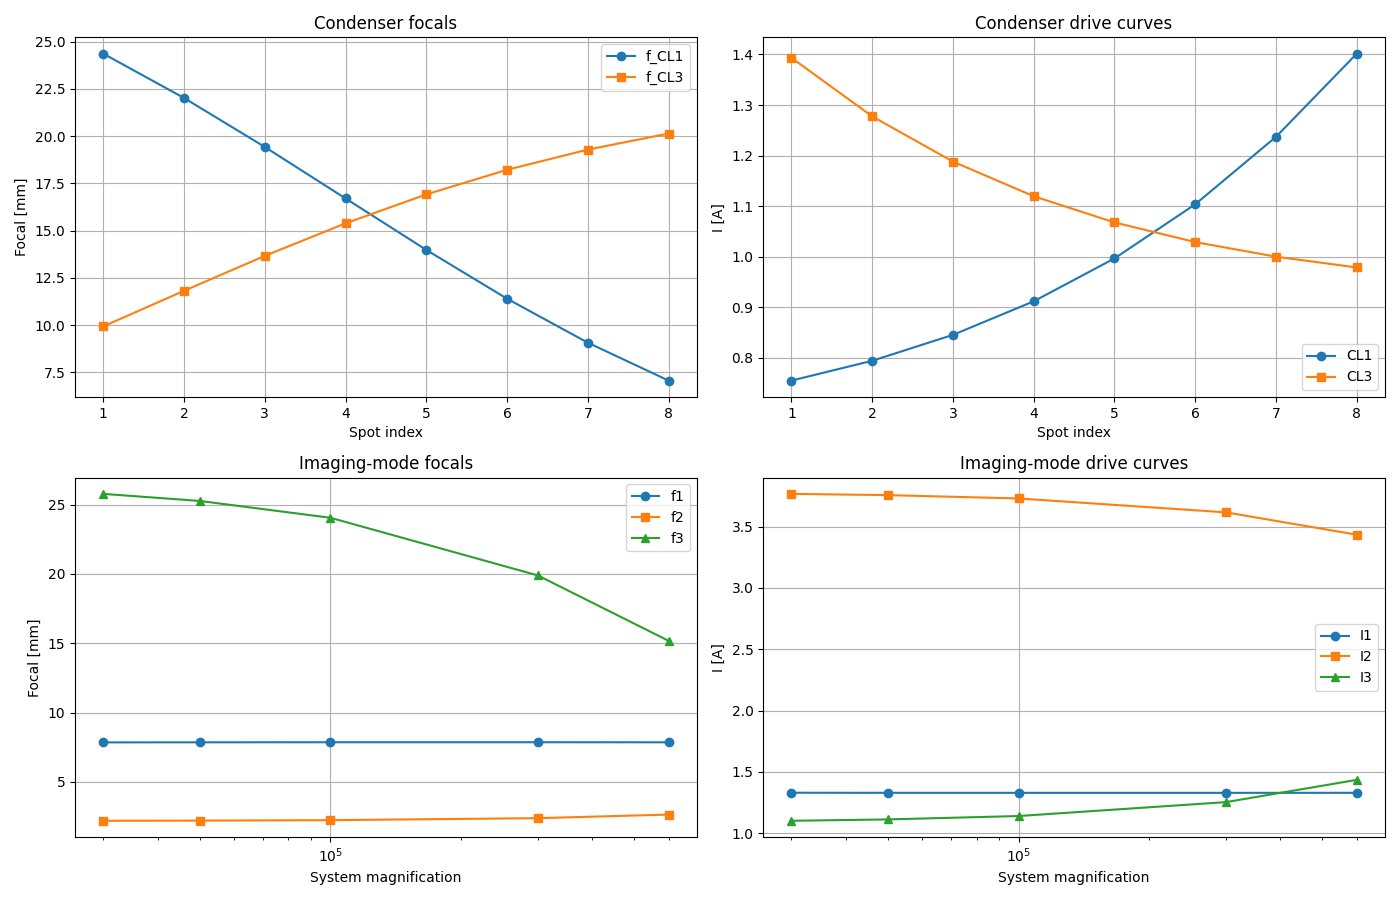

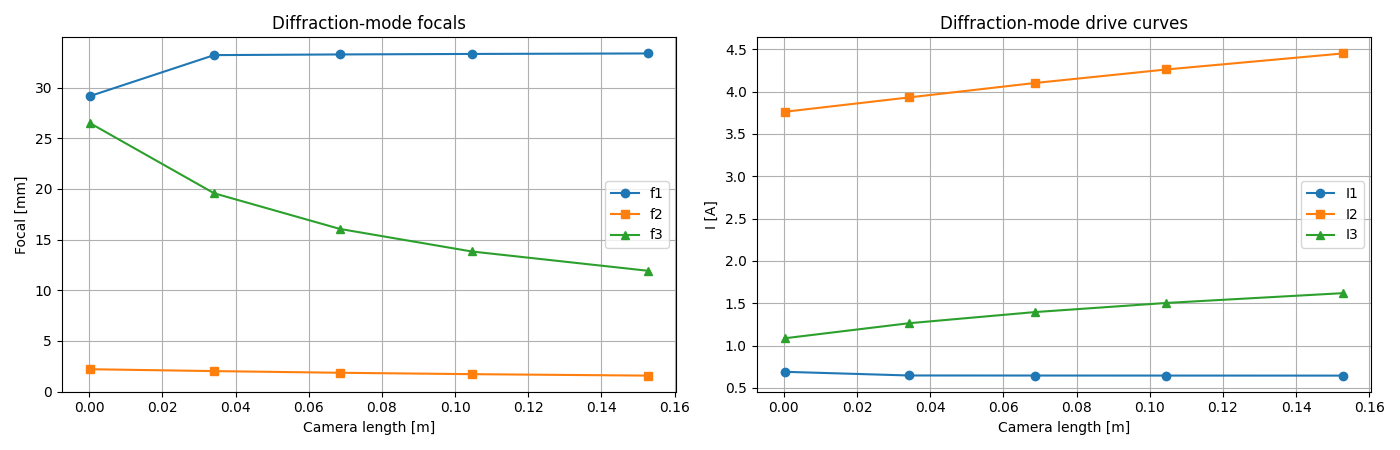

Rotation cancellation residual (imaging, max): 0.00 AT
Rotation cancellation residual (diffraction, max): 27798.99 AT
ObjPost: f=2.2258 mm, I=-2.497986 A (fixed)
PL1:     f=3.2178 mm, I=-3.116334 A (fixed)
Exported MicroscopeModel to: /Users/landers/TemGymCore/examples/microscope_models/data/microscope_design_curves.npz


In [16]:
# --- Four curve plots (condenser + imaging mode) ---
spot_idx = np.array([r['spot_index'] for r in results_cond], dtype=float)
f_cl1_mm = np.array([r['f_CL1'] for r in results_cond], dtype=float) * 1e3
f_cl3_mm = np.array([r['f_CL3'] for r in results_cond], dtype=float) * 1e3
i_cl1_a = np.array([r['I_A_CL1'] for r in results_cond], dtype=float)
i_cl3_a = np.array([r['I_A_CL3'] for r in results_cond], dtype=float)

x_sys = np.array(target_system_mags, dtype=float)
f1_mag_mm = np.array([r['f1_m'] for r in mag_results], dtype=float) * 1e3
f2_mag_mm = np.array([r['f2_m'] for r in mag_results], dtype=float) * 1e3
f3_mag_mm = np.array([r['f3_m'] for r in mag_results], dtype=float) * 1e3
i1_mag_a = np.array([r['I1_A'] for r in mag_results], dtype=float)
i2_mag_a = np.array([r['I2_A'] for r in mag_results], dtype=float)
i3_mag_a = np.array([r['I3_A'] for r in mag_results], dtype=float)

fig, axs = plt.subplots(2, 2, figsize=(14, 9))

axs[0, 0].plot(spot_idx, f_cl1_mm, 'o-', label='f_CL1')
axs[0, 0].plot(spot_idx, f_cl3_mm, 's-', label='f_CL3')
axs[0, 0].set(title='Condenser focals', xlabel='Spot index', ylabel='Focal [mm]')
axs[0, 0].legend()

axs[0, 1].plot(spot_idx, i_cl1_a, 'o-', label='CL1')
axs[0, 1].plot(spot_idx, i_cl3_a, 's-', label='CL3')
axs[0, 1].set(title='Condenser drive curves', xlabel='Spot index', ylabel='I [A]')
axs[0, 1].legend()

axs[1, 0].semilogx(x_sys, f1_mag_mm, 'o-', label='f1')
axs[1, 0].semilogx(x_sys, f2_mag_mm, 's-', label='f2')
axs[1, 0].semilogx(x_sys, f3_mag_mm, '^-', label='f3')
axs[1, 0].set(title='Imaging-mode focals', xlabel='System magnification', ylabel='Focal [mm]')
axs[1, 0].legend()

axs[1, 1].semilogx(x_sys, i1_mag_a, 'o-', label='I1')
axs[1, 1].semilogx(x_sys, i2_mag_a, 's-', label='I2')
axs[1, 1].semilogx(x_sys, i3_mag_a, '^-', label='I3')
axs[1, 1].set(title='Imaging-mode drive curves', xlabel='System magnification', ylabel='I [A]')
axs[1, 1].legend()

fig.tight_layout()
plt.show()

# --- Diffraction mode plots ---
x_cam_m = np.array([r['camera_length_target_m'] for r in diff_results], dtype=float)
f1_diff_mm = np.array([r['f1_m'] for r in diff_results], dtype=float) * 1e3
f2_diff_mm = np.array([r['f2_m'] for r in diff_results], dtype=float) * 1e3
f3_diff_mm = np.array([r['f3_m'] for r in diff_results], dtype=float) * 1e3
i1_diff_a = np.array([r['I1_A'] for r in diff_results], dtype=float)
i2_diff_a = np.array([r['I2_A'] for r in diff_results], dtype=float)
i3_diff_a = np.array([r['I3_A'] for r in diff_results], dtype=float)

fig_diff, axs_diff = plt.subplots(1, 2, figsize=(14, 4.5))
axs_diff[0].plot(x_cam_m, f1_diff_mm, 'o-', label='f1')
axs_diff[0].plot(x_cam_m, f2_diff_mm, 's-', label='f2')
axs_diff[0].plot(x_cam_m, f3_diff_mm, '^-', label='f3')
axs_diff[0].set(title='Diffraction-mode focals', xlabel='Camera length [m]', ylabel='Focal [mm]')
axs_diff[0].legend()

axs_diff[1].plot(x_cam_m, i1_diff_a, 'o-', label='I1')
axs_diff[1].plot(x_cam_m, i2_diff_a, 's-', label='I2')
axs_diff[1].plot(x_cam_m, i3_diff_a, '^-', label='I3')
axs_diff[1].set(title='Diffraction-mode drive curves', xlabel='Camera length [m]', ylabel='I [A]')
axs_diff[1].legend()

fig_diff.tight_layout()
plt.show()

# --- ObjPost / PL1 currents (both fixed by optics) ---
turns_objpost = sys_config['optics']['ObjPost']['turns']
turns_pl1 = sys_config['optics']['PL1']['turns']
Gc_objpost = sys_config['optics']['ObjPost']['Gc']
Gc_pl1 = sys_config['optics']['PL1']['Gc']
comp_sign = -1.0  # oppose IL rotation sign

ni_mag_total = np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in mag_results], dtype=float)
ni_diff_total = np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in diff_results], dtype=float)

# ObjPost current is fixed by M_obj (objective magnification)
ni_objpost_mag = np.full(ni_mag_total.shape, comp_sign * ni_objpost_mag, dtype=float)
ni_objpost_diff = np.full(ni_diff_total.shape, comp_sign * ni_objpost_mag, dtype=float)
# PL1 current is fixed by projector geometry
ni_pl1_mag = np.full(ni_mag_total.shape, comp_sign * ni_pl1_mag, dtype=float)
ni_pl1_diff = np.full(ni_diff_total.shape, comp_sign * ni_pl1_mag, dtype=float)

i_a_objpost_mag = ni_objpost_mag / turns_objpost
i_a_objpost_diff = ni_objpost_diff / turns_objpost
i_a_pl1_mag = ni_pl1_mag / turns_pl1
i_a_pl1_diff = ni_pl1_diff / turns_pl1

f_obj_from_current = 1.0 / (Gc_objpost * (turns_objpost * i_a_objpost_mag)**2)
if not np.allclose(f_obj_from_current, f_obj_required_m, rtol=1e-6):
    raise RuntimeError(f'ObjPost current does not realize required f_obj={f_obj_required_m*1e3:.4f} mm.')

f_pl1_from_current = 1.0 / (Gc_pl1 * (turns_pl1 * i_a_pl1_mag)**2)
if not np.allclose(f_pl1_from_current, f_pl1_target_m, rtol=1e-6):
    raise RuntimeError('PL1 current does not realize target focal length.')

net_ni_mag = ni_mag_total + ni_objpost_mag + ni_pl1_mag
net_ni_diff = ni_diff_total + ni_objpost_diff + ni_pl1_diff
print(f'Rotation cancellation residual (imaging, max): {np.max(np.abs(net_ni_mag)):.2f} AT')
print(f'Rotation cancellation residual (diffraction, max): {np.max(np.abs(net_ni_diff)):.2f} AT')

print(f'ObjPost: f={f_obj_required_m*1e3:.4f} mm, I={i_a_objpost_mag[0]:.6f} A (fixed)')
print(f'PL1:     f={f_pl1_target_m*1e3:.4f} mm, I={i_a_pl1_mag[0]:.6f} A (fixed)')

# --- Export MicroscopeModel ---
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'src').exists()), cwd)
export_path = repo_root / 'examples/microscope_models/data/microscope_design_curves.npz'
export_path.parent.mkdir(parents=True, exist_ok=True)

from temgym_core.constants import compute_rotation_angle_Gc_from_NI_focal_length
_, C_mini_Gc = compute_rotation_angle_Gc_from_NI_focal_length(
    focal_length=sys_config['optics']['f_Cmini_m'],
    NI=sys_config['optics']['Cmini']['turns'],
    Rc=Rc_phys,
    )
_, Obj_prefield_Gc = compute_rotation_angle_Gc_from_NI_focal_length(
    focal_length=sys_config['optics']['f_ObjPrefield_m'],
    NI=sys_config['optics']['ObjPrefield']['turns'],
    Rc=Rc_phys,
    )

CL1 = LensConfig('CL1', sys_config['geometry']['d_Source_to_CL1'], sys_config['optics']['CL1']['turns'], sys_config['optics']['CL1']['Gc'], Rc_phys, 0.0)
z_cl3 = CL1.z_position + sys_config['geometry']['d_CL1_to_CL3']
CL3 = LensConfig('CL3', z_cl3, sys_config['optics']['CL3']['turns'], sys_config['optics']['CL3']['Gc'], Rc_phys, 0.0)

z_aperture = z_cl3 + sys_config['geometry']['d_CL3_to_Aperture']
z_cmini = z_aperture + sys_config['geometry']['d_Aperture_to_Cmini']
Cmini = LensConfig('C_mini', z_cmini, sys_config['optics']['Cmini']['turns'], C_mini_Gc, Rc_phys, 0.0)

z_obj_prefield = z_cmini + sys_config['geometry']['d_Cmini_to_ObjPrefield']
ObjPrefield = LensConfig('Obj_prefield', z_obj_prefield, sys_config['optics']['ObjPrefield']['turns'], Obj_prefield_Gc, Rc_phys, 0.0)

z_sample = z_obj_prefield + sys_config['geometry']['d_ObjPrefield_to_Sample']
z_obj_post = z_sample + sys_config['geometry']['d_Sample_to_ObjPost']
ObjPost = LensConfig('Obj_post', z_obj_post, sys_config['optics']['ObjPost']['turns'], sys_config['optics']['ObjPost']['Gc'], Rc_phys, 0.0)

z_il1 = z_obj_post + d_ObjPost_to_IL1
IL1 = LensConfig('IL1', z_il1, sys_config['optics']['IL1']['turns'], sys_config['optics']['IL1']['Gc'], Rc_phys, 0.0)

z_il2 = z_il1 + sys_config['geometry']['d_IL1_to_IL2']
IL2 = LensConfig('IL2', z_il2, sys_config['optics']['IL2']['turns'], sys_config['optics']['IL2']['Gc'], Rc_phys, 0.0)

z_il3 = z_il2 + sys_config['geometry']['d_IL2_to_IL3']
IL3 = LensConfig('IL3', z_il3, sys_config['optics']['IL3']['turns'], sys_config['optics']['IL3']['Gc'], Rc_phys, 0.0)

z_pre_pl1_image = z_il3 + geometry_mag['d_il3_to_image']
z_pl1 = z_pre_pl1_image + geometry_proj['d_pre_pl1_image_to_pl1']
PL1 = LensConfig('PL1', z_pl1, sys_config['optics']['PL1']['turns'], sys_config['optics']['PL1']['Gc'], Rc_phys, 0.0)

lenses = (CL1, CL3, Cmini, ObjPrefield, ObjPost, IL1, IL2, IL3, PL1)

spot_currents_a = np.column_stack([
    [r['I_A_CL1'] for r in results_cond],
    [r['I_A_CL3'] for r in results_cond],
    np.ones(len(results_cond)),
    np.ones(len(results_cond)),
    np.zeros(len(results_cond)),
    np.zeros(len(results_cond)),
    np.zeros(len(results_cond)),
    np.zeros(len(results_cond)),
    np.zeros(len(results_cond)),
])

mag_currents_a = np.column_stack([
    np.zeros(len(mag_results)),
    np.zeros(len(mag_results)),
    np.ones(len(mag_results)),
    np.ones(len(mag_results)),
    i_a_objpost_mag,
    [r['I1_A'] for r in mag_results],
    [r['I2_A'] for r in mag_results],
    [r['I3_A'] for r in mag_results],
    i_a_pl1_mag,
])

diff_currents_a = np.column_stack([
    np.zeros(len(diff_results)),
    np.zeros(len(diff_results)),
    np.ones(len(diff_results)),
    np.ones(len(diff_results)),
    i_a_objpost_diff,
    [r['I1_A'] for r in diff_results],
    [r['I2_A'] for r in diff_results],
    [r['I3_A'] for r in diff_results],
    i_a_pl1_diff,
])

max_current = max(
    np.max(np.abs(spot_currents_a)),
    np.max(np.abs(mag_currents_a)),
    np.max(np.abs(diff_currents_a)),
)

spot_mode = OperatingMode(
    control_values=np.array([r['spot_index'] for r in results_cond], dtype=float),
    normalized_currents=spot_currents_a / max_current,
    full_scale_current=max_current,
    allow_signed_currents=True,
    )

mag_mode = OperatingMode(
    control_values=np.array(target_system_mags, dtype=float),
    normalized_currents=mag_currents_a / max_current,
    full_scale_current=max_current,
    allow_signed_currents=True,
    )

diff_mode = OperatingMode(
    control_values=np.array([r['camera_length_target_m'] for r in diff_results], dtype=float),
    normalized_currents=diff_currents_a / max_current,
    full_scale_current=max_current,
    allow_signed_currents=True,
    )

modes = {'spot': spot_mode, 'mag': mag_mode, 'diff': diff_mode}

z_condenser_stigmator = 0.5 * (float(z_cl3) + float(z_aperture))
z_objective_post_stigmator = 0.5 * (float(z_obj_post) + float(z_il1))

auxiliary = {
    'z_source': 0.0,
    'z_aperture': float(z_aperture),
    'd_CL3_to_Aperture_m': float(sys_config['geometry']['d_CL3_to_Aperture']),
    'd_Aperture_to_Cmini_m': float(sys_config['geometry']['d_Aperture_to_Cmini']),
    'z_sample': float(z_sample),
    'z_detector': float(z_pl1 + geometry_proj['d_pl1_to_detector']),
    'd_pl1_to_detector_m': float(geometry_proj['d_pl1_to_detector']),
    'M_obj': float(M_obj),
    'f_obj_required_m': float(f_obj_required_m),
    'v_obj_m': float(v_obj_m),
    'd_obj_image_to_il1_m': float(d_obj_image_to_il1),
    'd_bfp_to_il1_m': float(geometry_diff['d_bfp_to_il1']),
    'source_waist_m': float(virtual_source_diameter_nm * 1e-9),
    'ray_fan_half_angle_mrad': 0.5,
    'ray_fan_num_rays': 41,
    'sample_half_width_nm': 3000.0,
    'detector_half_width_mm': 1.0,
    'z_condenser_stigmator': float(z_condenser_stigmator),
    'z_objective_post_stigmator': float(z_objective_post_stigmator),
    'stigmator_focal_range_m': [-1.0, 1.0],
    'condenser_stigmator_fx_m': np.inf,
    'condenser_stigmator_fy_m': np.inf,
    'objective_post_stigmator_fx_m': np.inf,
    'objective_post_stigmator_fy_m': np.inf,
    'stigmator_current_range_a': [-2e-3, 2e-3],
    'stigmator_current_step_a': 1e-5,
    'condenser_stigmator_power_per_a': 400.0,
    'objective_post_stigmator_power_per_a': 400.0,
    'condenser_stigmator_ix_default_a': 0.0,
    'condenser_stigmator_iy_default_a': 0.0,
    'objective_post_stigmator_ix_default_a': 0.0,
    'objective_post_stigmator_iy_default_a': 0.0,
    'imaging_mode_source': 'frozen_table_from_archived_study',
    'diffraction_mode_source': 'least_squares_bfp_relay_seeded_from_imaging',
    'diffraction_camera_lengths_m': [float(x) for x in x_cam_m],
}

model = MicroscopeModel(
    voltage=U_accel_V,
    lenses=lenses,
    modes=modes,
    auxiliary=auxiliary,
)
model.to_npz(export_path)
print(f'Exported MicroscopeModel to: {export_path}')

In [17]:
summary_mag = [{
    'M_mag': float(r['M_mag']),
    'f1_m': float(r['f1_m']),
    'f2_m': float(r['f2_m']),
    'f3_m': float(r['f3_m']),
    'I1_A': float(r['I1_A']),
    'I2_A': float(r['I2_A']),
    'I3_A': float(r['I3_A']),
    'AT1': float(r['AT1']),
    'AT2': float(r['AT2']),
    'AT3': float(r['AT3']),
    'A_actual': float(r['A_actual']),
    'B_m': float(r['B_m']),
} for r in mag_results]

summary_diff = [{
    'camera_length_target_m': float(r['camera_length_target_m']),
    'camera_length_actual_m': float(r['camera_length_actual_m']),
    'camera_length_rel_err': float(r['camera_length_rel_err']),
    'f1_m': float(r['f1_m']),
    'f2_m': float(r['f2_m']),
    'f3_m': float(r['f3_m']),
    'I1_A': float(r['I1_A']),
    'I2_A': float(r['I2_A']),
    'I3_A': float(r['I3_A']),
    'A_actual': float(r['A_actual']),
    'B_m': float(r['B_m']),
    'theta_err_vs_imaging_target': float(r['theta_err_vs_imaging_target']),
} for r in diff_results]

summary_cond = [{
    'spot_index': int(r['spot_index']),
    'f_CL1': float(r['f_CL1']),
    'f_CL3': float(r['f_CL3']),
    'I_A_CL1': float(r['I_A_CL1']),
    'I_A_CL3': float(r['I_A_CL3']),
} for r in results_cond]

import pprint
pprint.pp({
    'mag_results': summary_mag,
    'diff_results': summary_diff,
    'results_cond': summary_cond,
    'theta_target': float(theta_target),
})

{'mag_results': [{'M_mag': -10.0,
                  'f1_m': 0.007853640185424235,
                  'f2_m': 0.0022016954047385756,
                  'f3_m': 0.025774008628069712,
                  'I1_A': 1.3298365086939166,
                  'I2_A': 3.7674404194421567,
                  'I3_A': 1.1011184156566372,
                  'AT1': 3989.5095260817498,
                  'AT2': 7534.880838884314,
                  'AT3': 2202.2368313132743,
                  'A_actual': -9.999999999999948,
                  'B_m': 5.944333913987508e-18},
                 {'M_mag': -16.666666666666668,
                  'f1_m': 0.007860085949001856,
                  'f2_m': 0.002213688894488774,
                  'f3_m': 0.025264954013827473,
                  'I1_A': 1.3292911221762411,
                  'I2_A': 3.757220797826677,
                  'I3_A': 1.1121561168186147,
                  'AT1': 3987.8733665287236,
                  'AT2': 7514.441595653354,
                  'AT3': 2224.31